In [135]:
import torch
import numpy as np 
import matplotlib.pyplot as plt 
from torch import nn, Tensor
import time
import os

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)
if not os.path.exists("./models"):
    os.mkdir("./models")

cuda:0


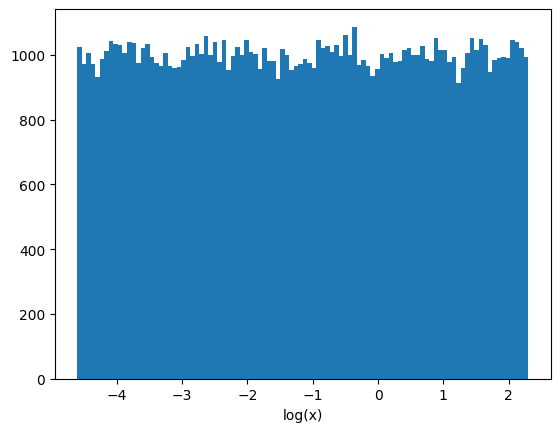

In [136]:
def sample_log_uniform(low, high, size, device=None):
    """
    low, high: scalars (floats), low > 0
    size: tuple, e.g. (B,)
    """
    u = torch.rand(size, device=device)
    log_low = torch.log(torch.tensor(low, device=device))
    log_high = torch.log(torch.tensor(high, device=device))
    return torch.exp(log_low + u * (log_high - log_low)).to(device)


def sample_prior(B, device=None):
    gamma = sample_log_uniform(0.05, 0.5, (B, 1), device)
    R0 = sample_log_uniform(0.5, 5.0, (B, 1), device)
    beta = R0 * gamma
    return torch.cat([beta, gamma], dim=1).to(device)


def sample_init_dist(B, device=None):
    return torch.randn(size=(B, 2)).to(device)


samples = sample_log_uniform(0.01, 10.0, (100_000,))
plt.hist(torch.log(samples).numpy(), bins=100)
plt.xlabel("log(x)")
plt.show()

tensor([[0.2998, 0.3009],
        [0.4497, 0.4514]])


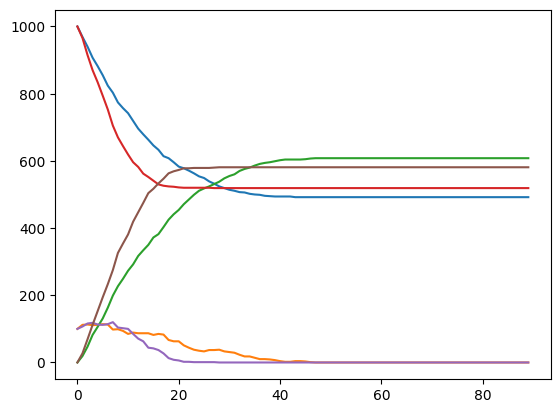

In [137]:
def simulate(phi, sir=(1000, 100, 0), T=90):
    S, I, R = sir
    S = torch.zeros(phi.shape[0], device=phi.device) + S
    I = torch.zeros(phi.shape[0], device=phi.device) + I
    R = torch.zeros(phi.shape[0], device=phi.device) + R
    N = S + I + R
    states = torch.zeros(phi.shape[0], T, 3, device=phi.device)
    for t in range(0, T):
        states[:, t, 0] = S
        states[:, t, 1] = I
        states[:, t, 2] = R

        p_inf = 1 - torch.exp(-phi[:, 0] * I / N)
        p_rec = 1 - torch.exp(-phi[:, 1])

        new_inf = torch.binomial(S, p_inf)
        new_rec = torch.binomial(I, p_rec)

        S = S - new_inf
        I = I + new_inf - new_rec
        R = R + new_rec

    states[:, T-1, 0] = S
    states[:, T-1, 1] = I
    states[:, T-1, 2] = R
    return states        
    
sir = (1000, 100, 0)
phi = sample_prior(2)
phi[1, :] = 1.5*phi[0, :] 
print(phi)
x_0, x_1 = simulate(phi, sir, 90).cpu()
S, I, R = x_0[:, 0], x_0[:, 1], x_0[:, 2]
plt.plot(S)
plt.plot(I)
plt.plot(R)
S, I, R = x_1[:, 0], x_1[:, 1], x_1[:, 2]
plt.plot(S)
plt.plot(I)
plt.plot(R)

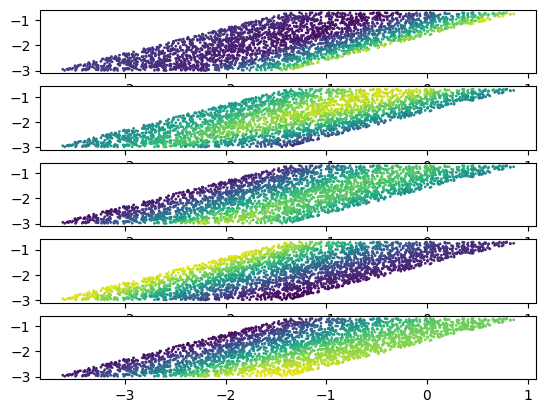

In [138]:
def safe_div(a, b, eps=1e-8):
    return a / (b + eps)

def handmade_summary(x, eps=1e-8):
    S = x[:, :, 0]
    I = x[:, :, 1]
    R = x[:, :, 2]
    batch, T = I.shape

    N = S[:, 0] + I[:, 0] + R[:, 0]
    N = N.clamp(min=eps)

    
    I_peak, t_peak = I.max(dim=1)            
    t_peak = t_peak.to(torch.float32) / float(max(1, T - 1))
    t_peak = t_peak.unsqueeze(1)             

    I_peak_frac = safe_div(I_peak, N).unsqueeze(1)
    
    I_mean_frac = safe_div(I.mean(dim=1), N).unsqueeze(1)

    R_final_frac = safe_div(R[:, -1], N).unsqueeze(1)

    S_final_frac = safe_div(S[:, -1], N).unsqueeze(1)

    
    s = torch.cat([t_peak, I_peak_frac, I_mean_frac, R_final_frac, S_final_frac], dim=1).to(x.device)
    
    B = torch.tensor([[-0.6543, -1.0543,  0.4823, -0.4612,  0.7340],
                      [ 2.6280, -1.6988, -0.6246, -0.0949, -0.3497],
                      [ 0.4116, -0.8507, -0.1116, -0.5067,  1.4959],
                      [-0.2124, -0.1211, -0.8651, -1.2937,  1.2938],
                      [ 0.0257, -0.9242, -1.4133,  0.3826, -1.0719]]).to(x.device)
    
    s = torch.matmul(s, B)
    
    return s

def visualize_summary_features(summary):
    phi = sample_prior(3000)
    x = simulate(phi, (1000, 500, 0), 90)
    s = summary(x)
    _, ax = plt.subplots(s.shape[1], 1, sharey=True)
    for i in range(s.shape[1]):
        ax[i].scatter(torch.log(phi[:, 0]), torch.log(phi[:, 1]), c=s[:, i], s=1)
        # ax[i].scatter(phi[:, 0], phi[:, 1], c=s[:, i], s=1)

visualize_summary_features(handmade_summary)

In [139]:
class CondFlow(nn.Module):
    def __init__(self, phi_dim, x_dim, h):
        super().__init__()
        self.dim = phi_dim
        self.net = nn.Sequential(
            nn.Linear(1 + x_dim + phi_dim, h), nn.ReLU(),
            nn.Linear(h, h), nn.ReLU(),
            nn.Linear(h, h), nn.ReLU(),
            nn.Linear(h, phi_dim)
        )
    
    def forward(self, t, x, phi):
        return self.net(torch.cat((t, x, phi), dim=-1))
    
    def step(self, phi, x, t_start, t_end):
        t_start = t_start.view(1, 1).expand(phi.shape[0], 1)
        t_end = t_end.view(1, 1).expand(phi.shape[0], 1)
        
        t_mid = (t_end + t_start) / 2
        phi_mid = phi + self.forward(t=t_start, x=x, phi=phi) * (t_mid - t_start)
        return  phi + self.forward(t=t_mid, x=x, phi=phi_mid) * (t_end - t_start)

model = CondFlow(2, 5, 16)
beta, gamma = 0.5, 0.5
sir = (1000, 100, 0)

phi = torch.tensor([[beta, gamma]])
x = simulate(phi, sir, 90)
s = handmade_summary(x)
t = torch.tensor([[0.0]])
model(t=t, x=s, phi=phi)

tensor([[-0.0354,  0.2170]], grad_fn=<AddmmBackward0>)

tensor([[0.4284, 0.1615]], device='cuda:0')
Epoch: 0, Loss: 1.2362
Epoch: 100, Loss: 0.9846
Epoch: 200, Loss: 0.7455
Epoch: 300, Loss: 0.4767
Epoch: 400, Loss: 0.3728
Epoch: 500, Loss: 0.3454
Epoch: 600, Loss: 0.2997
Epoch: 700, Loss: 0.2712
Epoch: 800, Loss: 0.2457
Epoch: 900, Loss: 0.2518
Epoch: 1000, Loss: 0.2509


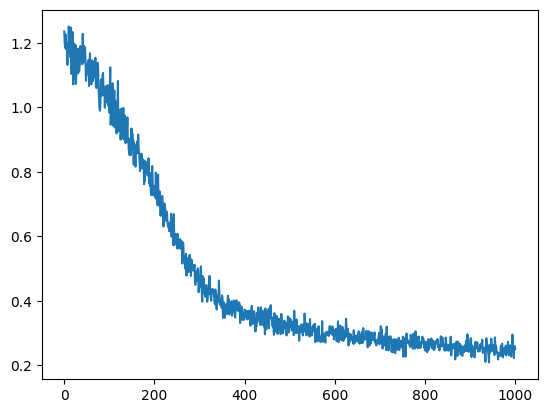

In [140]:
import torch.distributions as dist

beta_dist = dist.Beta(torch.tensor(0.5), torch.tensor(0.5))

def train(model, 
          summary,
          sim_parameters,
          optimizer, 
          loss_fn,
          dataset=None,
          epochs=2000,
          path="./models",
          show_every=None, 
          show_loss=False):
    
    model.train()
    sir = sim_parameters["sir"]
    T_max = sim_parameters["T_max"]

    losses = []
    min_loss = torch.inf

    if not show_every is None:
        show_loss = True

    
    for i in range(epochs+1):
        if dataset is None:
            phi_1 = sample_prior(1000).to(device)
        else:
            phi_1 = dataset.squeeze(0)
        x = simulate(phi_1, sir, T_max).to(device)
        s = summary(x).to(device)
        
        phi_0 = sample_init_dist(phi_1.shape[0]).to(device)
        t = torch.rand(phi_1.shape[0], 1).to(device)
        # t = beta_dist.sample((phi_1.shape[0], 1)).to(device)
        
        phi_t = (1 - t) * phi_0 + t * phi_1
        dphi_t = phi_1 - phi_0

        v = model(t=t, x=s, phi=phi_t)
        loss = loss_fn(v, dphi_t)
        losses.append(loss.detach().item())

        if loss < min_loss:
            torch.save(model.state_dict(), path)
        
        if show_loss and i % show_every == 0:
            print(f"Epoch: {i}, Loss: {losses[i]:.4f}")#, Time: {(time.time() - s):.2f}")
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return losses

def pipeline(model,
             summary,
             optimizer,
             sim_parameters,
             train_model=True,
             epochs=2000, 
             show_every=200,
             device=torch.device(device)):
    if train_model:
        model.train()
        
        loss = torch.nn.MSELoss()
        
        datetime = time.strftime("%Y-%m-%d_%H_%M_%S")
        path = f"./models/SIR_{datetime}.pth.tar.gz" 
        
        losses = train(model, 
                       summary, 
                       sim_parameters, 
                       optimizer, 
                       loss, 
                       path=path, 
                       epochs=epochs, 
                       show_every=show_every)
        plt.plot(losses)
        return losses
    
    else:
        assert os.path.exists(path)
        model.load_state_dict(torch.load(path, weights_only=True, map_location=torch.device(device)))
        model.eval()

phi = torch.tensor([[0.4284, 0.1615]]).to(device)
x = simulate(phi)
print(phi)

simple_model = CondFlow(2, 5, 64).to(device)
optimizer = torch.optim.Adam(simple_model.parameters(), lr=1e-4)
sim_parameters = {"sir": (1000, 100, 0),
                  "T_max": 90}

losses = pipeline(simple_model,
                  handmade_summary,
                  optimizer,
                  sim_parameters,
                  train_model=True,
                  epochs=1000, 
                  show_every=100)

True: tensor([0.4284, 0.1615]), Mean: tensor([0.5387, 0.2015]), STD: tensor([0.2629, 0.1621])


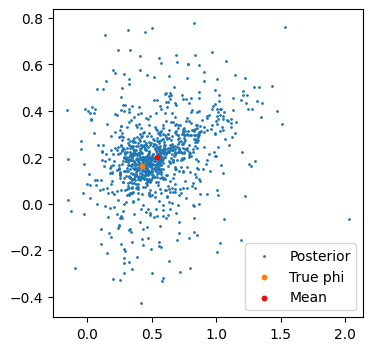

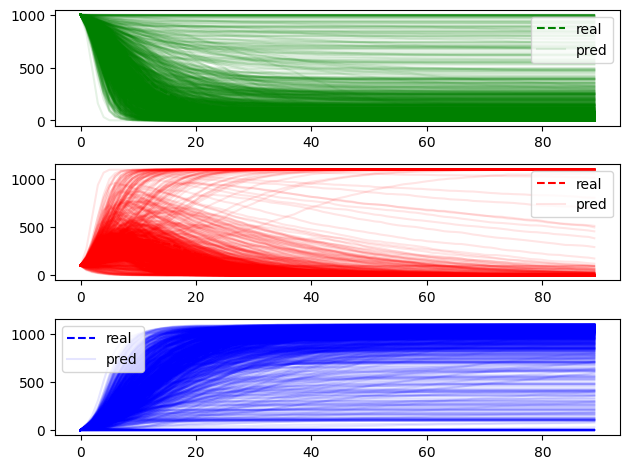

In [141]:
def plot_posterior(posterior, 
                   real_phi,
                   log_scale=False):
    mean = posterior.mean(dim=1)
    std = (posterior - mean[:, None, :]).pow(2).mean(dim=1).pow(0.5)
        
    if phi.shape[0] == 1:
        _, ax = plt.subplots(1, 1, figsize=(4, 4))
        if log_scale:
            ax.scatter(torch.log(posterior[0, :, 0]).cpu(), torch.log(posterior[0, :, 1]).cpu(), s=1, label="Posterior")
            ax.scatter(torch.log(real_phi[0, 0]).cpu(), torch.log(real_phi[0, 1]).cpu(), s=10, label="True phi")
            ax.scatter(torch.log(mean[0, 0]).cpu(), torch.log(mean[0, 1]).cpu(), s=10, label="Mean", color="red")
        else:
            ax.scatter(posterior[0, :, 0].cpu(), posterior[0, :, 1].cpu(), s=1, label="Posterior")
            ax.scatter(real_phi[0, 0].cpu(), real_phi[0, 1].cpu(), s=10, label="True phi")
            ax.scatter(mean[0, 0].cpu(), mean[0, 1].cpu(), s=10, label="Mean", color="red")
        ax.legend()
    
    else:
        _, ax = plt.subplots(max(real_phi.shape[0], 2), 1, figsize=(4, 4 * (max(real_phi.shape[0], 2))))

        for i in range(x.shape[0]):
            if log_scale:
                ax[i].scatter(torch.log(posterior[i, :, 0]).cpu(), torch.log(posterior[i, :, 1]).cpu(), s=1, label="Posterior")
                ax[i].scatter(torch.log(real_phi[i, 0]).cpu(), torch.log(real_phi[i, 1]).cpu(), s=10, label="True phi")
                ax[i].scatter(torch.log(mean[i, 0]).cpu(), torch.log(mean[i, 1]).cpu(), s=10, label="Mean", color="red")
            else:
                ax[i].scatter(posterior[i, :, 0].cpu(), posterior[i, :, 1].cpu(), s=1, label="Posterior")
                ax[i].scatter(real_phi[i, 0].cpu(), real_phi[i, 1].cpu(), s=10, label="True phi")
                ax[i].scatter(mean[i, 0].cpu(), mean[i, 1].cpu(), s=10, label="Mean", color="red")
            ax[i].legend()
    

def sample_posterior(model, x, 
                     n_steps=10, 
                     n_samples=1000):
    model.eval()
    posterior = []
    time_steps = torch.linspace(0.0, 1.0, n_steps + 1).to(device)
    
    for i in range(n_samples):
        # pred_phi = torch.randn(size=(x.shape[0], 2)).to(device)
        pred_phi = sample_init_dist(x.shape[0]).to(device)
        for i in range(n_steps):
            pred_phi = model.step(phi=pred_phi, x=x, t_start=time_steps[i], t_end=time_steps[i+1])
        posterior.append(pred_phi[:, None, :])

    posterior = torch.cat(posterior, dim=1).detach()
    return posterior


def fast_sample_posterior(model, 
                          x, 
                          n_steps=10, 
                          n_samples=1000):
    model.eval()
    time_steps = torch.linspace(0.0, 1.0, n_steps + 1).to(device)

    x_expanded = x.expand(n_samples, x.shape[-1])
    pred_phi = sample_init_dist(n_samples).to(device)
    for i in range(n_steps):
        pred_phi = model.step(phi=pred_phi, x=x_expanded, t_start=time_steps[i], t_end=time_steps[i+1])
    return pred_phi.unsqueeze(0).detach()


def validate(phi,
             model,
             summary,
             plot=False):
    
    x_real = simulate(phi).detach().cpu()
    s = summary(x_real).to(device)
    
    phi_pred = fast_sample_posterior(model, 
                                     s, 
                                     n_steps=32, 
                                     n_samples=1000).detach().cpu()

    mean = phi_pred.mean(dim=1)
    std = (phi_pred - mean[:, None, :]).pow(2).mean(dim=1).pow(0.5)
    for i in range(mean.shape[0]):
        print(f"True: {phi[i].cpu()}, Mean: {mean[i]}, STD: {std[i]}")
    
    if plot:
        plot_posterior(phi_pred, phi)
        
        x_pred = simulate(phi_pred[0]).detach().cpu()

        S_real, I_real, R_real = x_real[0, :, 0], x_real[0, :, 1], x_real[0, :, 2]
        
        _, ax = plt.subplots(3, 1)
        ax[0].plot(S_real, linestyle="--", color="green", label="real")
        ax[1].plot(I_real, linestyle="--", color="red", label="real")
        ax[2].plot(R_real, linestyle="--", color="blue", label="real")
        
        for i in range(x_pred.shape[0]):
            S_pred, I_pred, R_pred = x_pred[i, :, 0], x_pred[i, :, 1], x_pred[i, :, 2]
        
            ax[0].plot(S_pred, color="green", label="pred", alpha=0.1)
            ax[1].plot(I_pred, color="red",   label="pred", alpha=0.1)
            ax[2].plot(R_pred, color="blue",  label="pred", alpha=0.1)
            if i == 0:
                [ax[j].legend() for j in range(3)]
        plt.tight_layout()

validate(phi, simple_model, handmade_summary, plot=True)

In [142]:
def seq_pipeline(x,
                 model,
                 summary,
                 optimizer,
                 sim_parameters,
                 dataset_size=10000,
                 runs=3,
                 train_model=True,
                 epochs=1000, 
                 show_every=200,
                 device=torch.device(device)):
    if train_model:
        model.train()
        
        loss = torch.nn.MSELoss()
        
        datetime = time.strftime("%Y-%m-%d_%H_%M_%S")
        path = f"./models/SIR_{datetime}.pth.tar.gz" 
        
        losses = []
        print("Round 1")
        losses += train(model, 
                       summary, 
                       sim_parameters, 
                       optimizer, 
                       loss, 
                       path=path, 
                       epochs=epochs, 
                       show_every=show_every)
        validate(phi, model, summary, plot=True)
        
        s = summary(x).to(device)
        for i in range(runs - 1):
            print(f"Round {i+2}")
            dataset = fast_sample_posterior(model, s, n_samples=dataset_size)
            losses += train(model, 
                            summary, 
                            sim_parameters, 
                            optimizer, 
                            loss, 
                            dataset=dataset,
                            path=path, 
                            epochs=epochs, 
                            show_every=show_every)
            validate(phi, model, summary, plot=True)
        return losses, dataset
    
    else:
        assert os.path.exists(path)
        model.load_state_dict(torch.load(path, weights_only=True, map_location=torch.device(device)))
        model.eval()

Round 1
Epoch: 0, Loss: 1.2535
Epoch: 200, Loss: 0.8372
Epoch: 400, Loss: 0.3761
Epoch: 600, Loss: 0.2971
Epoch: 800, Loss: 0.2718
Epoch: 1000, Loss: 0.2641
True: tensor([0.4284, 0.1615]), Mean: tensor([0.6217, 0.2155]), STD: tensor([0.2539, 0.1570])
Round 2
Epoch: 0, Loss: 0.3678
Epoch: 200, Loss: 0.2317
Epoch: 400, Loss: 0.2090
Epoch: 600, Loss: 0.1917
Epoch: 800, Loss: 0.1793
Epoch: 1000, Loss: 0.1665
True: tensor([0.4284, 0.1615]), Mean: tensor([0.5012, 0.2109]), STD: tensor([0.1359, 0.0906])
Round 3
Epoch: 0, Loss: 0.1220
Epoch: 200, Loss: 0.1044
Epoch: 400, Loss: 0.0927
Epoch: 600, Loss: 0.0801
Epoch: 800, Loss: 0.0825
Epoch: 1000, Loss: 0.0798
True: tensor([0.4284, 0.1615]), Mean: tensor([0.3592, 0.1426]), STD: tensor([0.0743, 0.0603])
Round 4
Epoch: 0, Loss: 0.0652
Epoch: 200, Loss: 0.0533
Epoch: 400, Loss: 0.0526
Epoch: 600, Loss: 0.0507
Epoch: 800, Loss: 0.0477
Epoch: 1000, Loss: 0.0454
True: tensor([0.4284, 0.1615]), Mean: tensor([0.5128, 0.1999]), STD: tensor([0.0501, 0.034

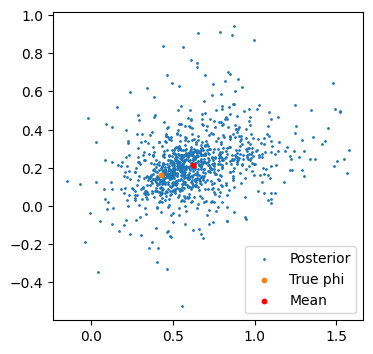

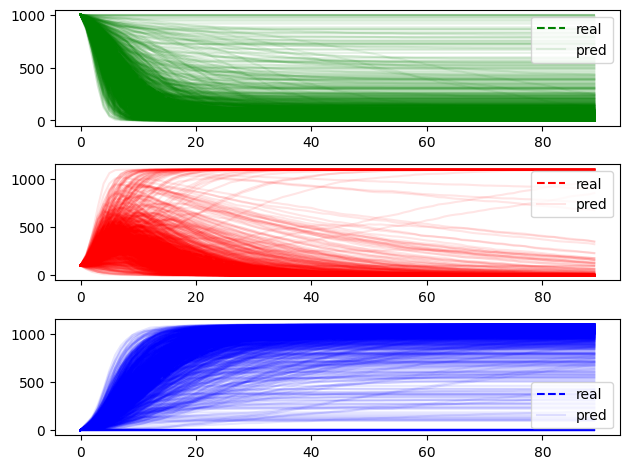

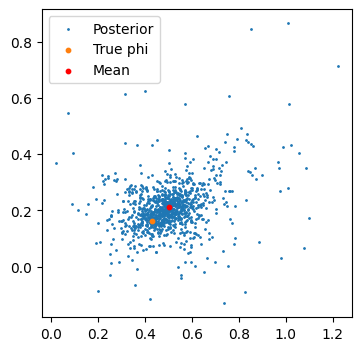

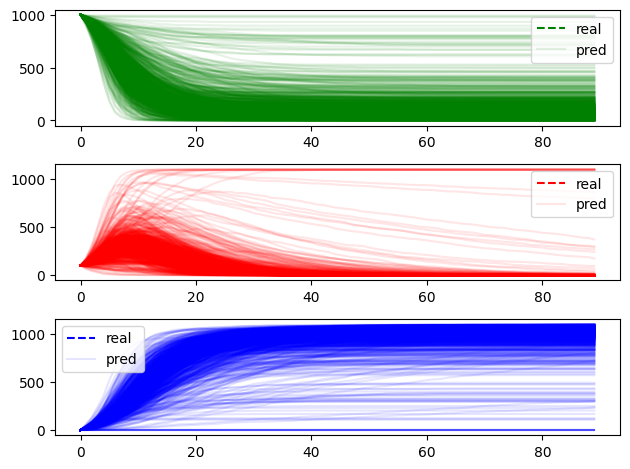

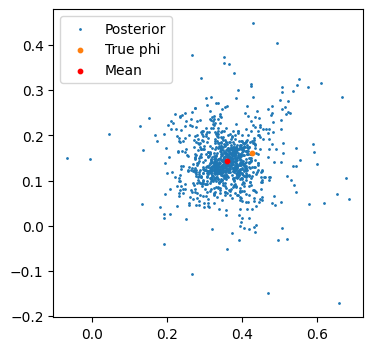

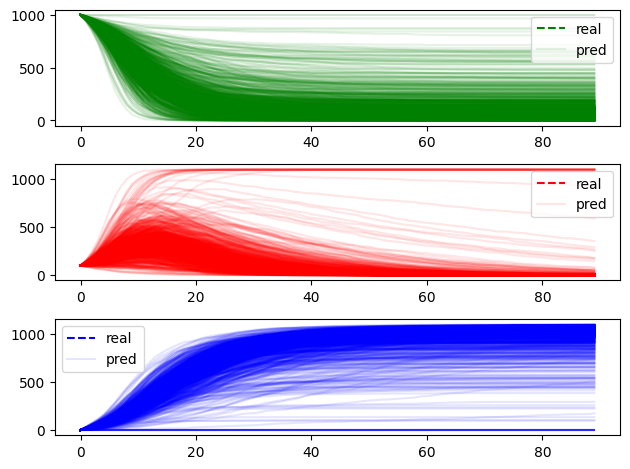

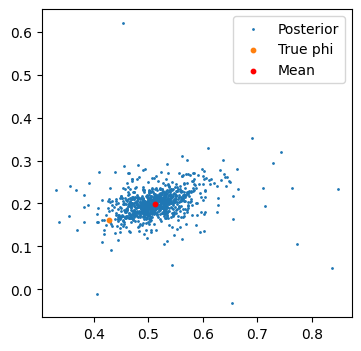

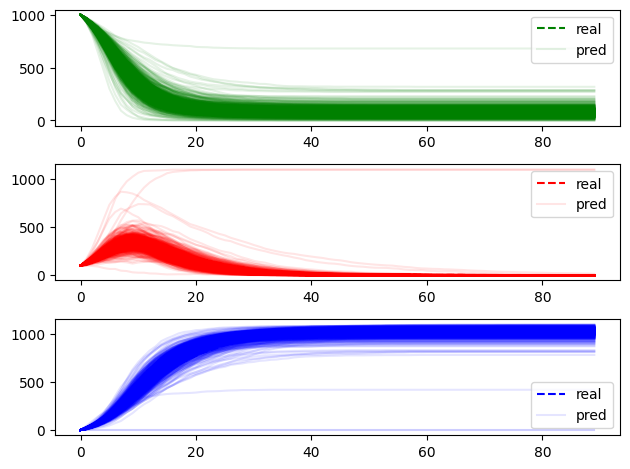

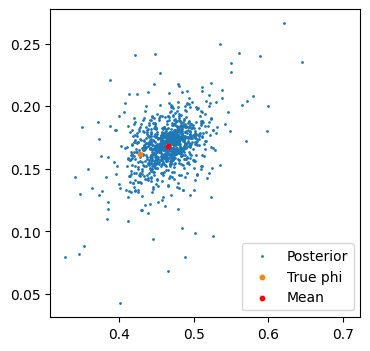

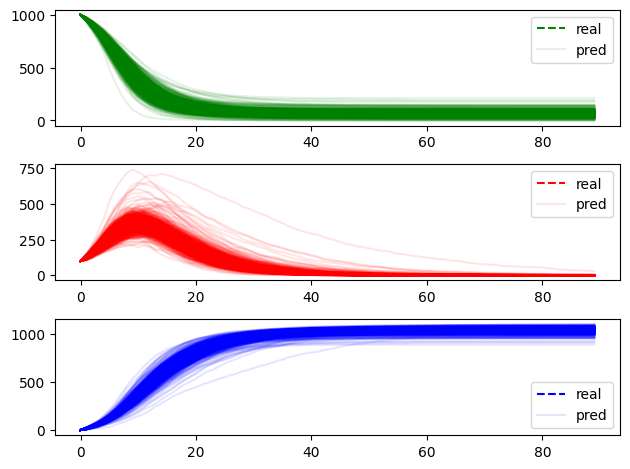

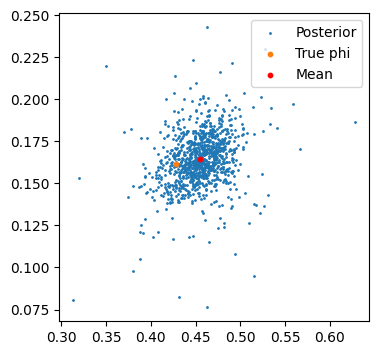

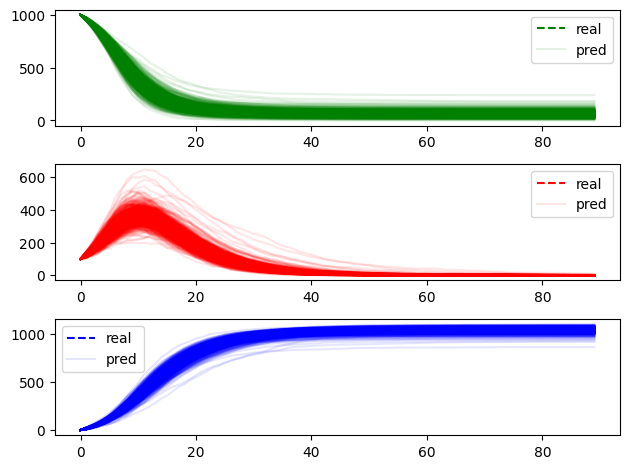

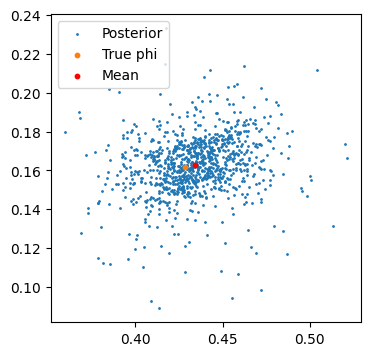

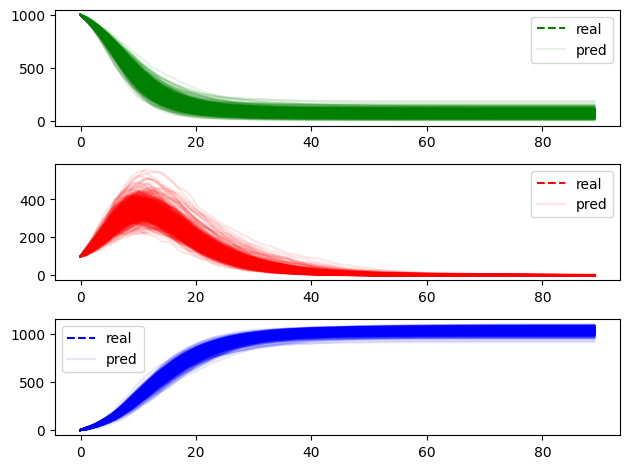

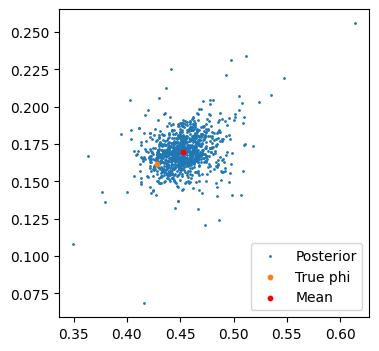

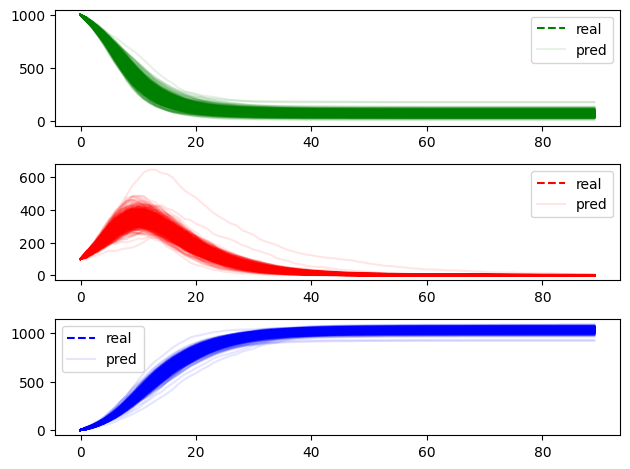

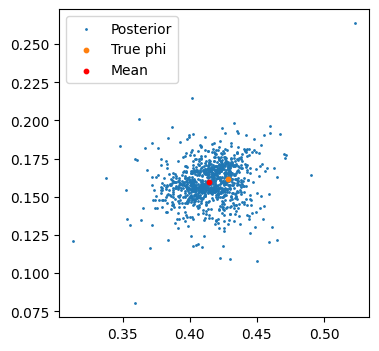

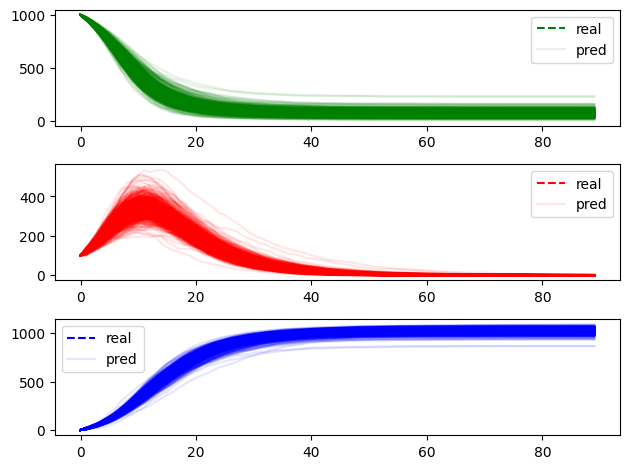

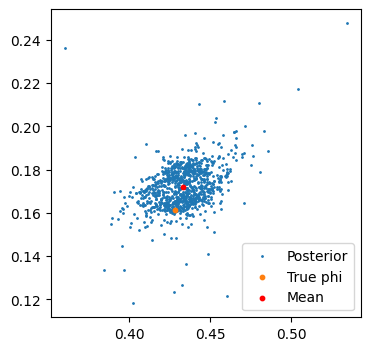

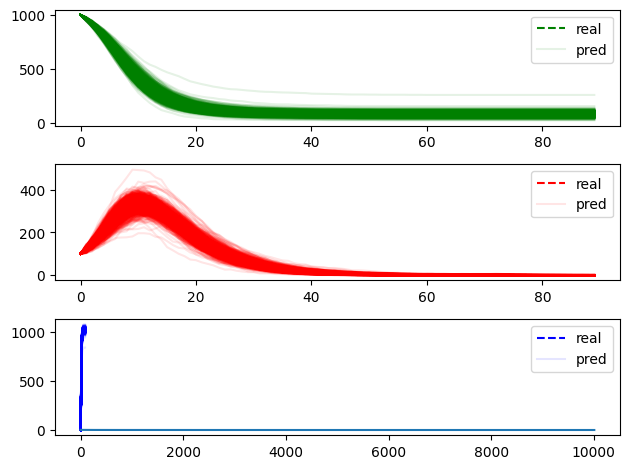

In [143]:
seq_model = CondFlow(2, 5, 64).to(device)
optimizer = torch.optim.Adam(seq_model.parameters(), lr=1e-4)
sim_parameters = {"sir": (1000, 100, 0),
                  "T_max": 90}

losses, dataset = seq_pipeline(x,
                      seq_model,
                      handmade_summary,
                      optimizer,
                      sim_parameters,
                      train_model=True,
                      dataset_size=10000,
                      runs=10,
                      epochs=1000, 
                      show_every=200)
plt.plot(losses)

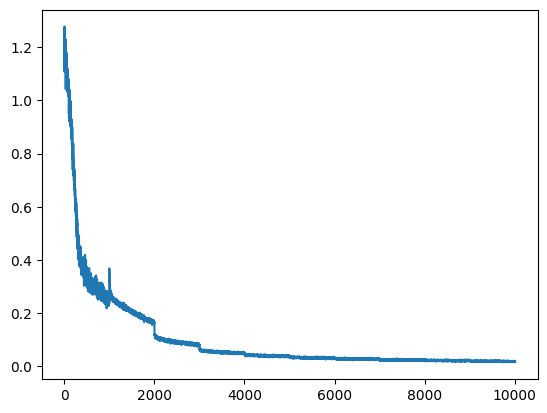

In [148]:
plt.plot(losses)

True: tensor([0.4284, 0.1615]), Mean: tensor([0.4328, 0.1663]), STD: tensor([0.0147, 0.0092])


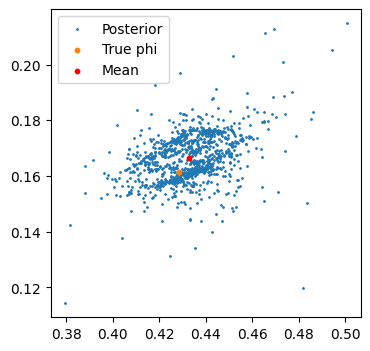

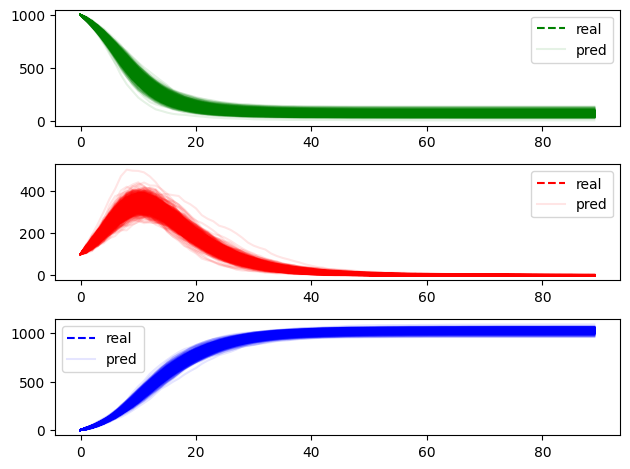

In [153]:
validate(phi, seq_model, handmade_summary, plot=True)